Comparing with SMC-ABC

In [3]:
%pip install pyabc numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [50]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import pyabc
import matplotlib.pyplot as plt
from pyabc.visualization import plot_kde_matrix, plot_epsilons
from pyabc.sampler import SingleCoreSampler


In [51]:
# ==========================================
# 1. Real Data Loading
# ==========================================
import pandas as pd
import numpy as np
import os
import tempfile

# Load your collected sensor data here. 
file_path = './data/sequence_2/sequence_2_timeseries.csv'
min_time = 20.0  # Cutoff time from main.ipynb

try:
    df_data = pd.read_csv(file_path)
    
    # --- Minimum Time Filter (from main.ipynb) ---
    original_len = len(df_data)
    df_data = df_data[df_data['relative_time_sec'] >= min_time].copy()
    print(f"Time trim: Removed {original_len - len(df_data)} frames prior to t={min_time:.2f}s")
    
    # Extract arrays
    time_steps = df_data['relative_time_sec'].values
    sensor_data = df_data['max_temperature_kelvin'].values
    
    # CRITICAL: Shift the time series so it starts at t=0
    # This ensures newtons_cooling() correctly uses T0 at the first time step
    time_steps = time_steps - time_steps[0]
    
    print(f"Successfully loaded {len(time_steps)} data points.")
except FileNotFoundError:
    print(f"Warning: '{file_path}' not found. Generating a dummy dataset so the script can run.")

# Set the initial temperature to the very first sensor reading (after the trim)
T0 = sensor_data[0]

# The updated mathematical equation with a t_0 shift
def newtons_cooling(k, T_env, t, t_0, T_initial):
    return T_env + (T_initial - T_env) * np.exp(-k * (t - t_0))

# Package the real observations for pyabc
observation = {"temperature_curve": sensor_data}

Time trim: Removed 3 frames prior to t=20.00s
Successfully loaded 24 data points.


In [67]:
# ==========================================
# 2. SMC-ABC Configuration
# ==========================================
prior = pyabc.Distribution(
    k=pyabc.RV("uniform", 0.001, 0.1),
    T_env=pyabc.RV("uniform", 290.0, 315.0),
    t_0=pyabc.RV("uniform", -5.0, 5.0),
    sigma=pyabc.RV("uniform", 0.1, 5.0), # Search for sensor noise between 0.1 and 5 degrees
    T_initial=pyabc.RV("uniform", 300.0, 400.0)
)

def newtons_cooling(k, T_env, t, t_0, T_initial):
    """Newton's Law of Cooling with a time offset (t_0)"""
    return T_env + (T_initial - T_env) * np.exp(-k * (t - t_0))

def abc_model(parameters):
    k_sim = parameters["k"]
    T_env_sim = parameters["T_env"]
    t_0_sim = parameters["t_0"]
    sigma_sim = parameters["sigma"]

    clean_curve = newtons_cooling(k_sim, T_env_sim, time_steps, t_0_sim, T0)

    # The model now outputs noisy synthetic data
    noisy_curve = clean_curve + np.random.normal(0, sigma_sim, size=len(time_steps))

    return {"temperature_curve": noisy_curve}

In [73]:
# ==========================================
# 3. Execution (Fixed for Jupyter)
# ==========================================
# This is the line where we initialize ABCSMC and add the SingleCoreSampler
# Use an adaptive distance metric to prevent early steep drops from dominating

from pyabc.sampler import SingleCoreSampler

distance = pyabc.AdaptivePNormDistance(p=2)

abc = pyabc.ABCSMC(
    models=abc_model,
    parameter_priors=prior,
    distance_function=distance,
    population_size=pyabc.ConstantPopulationSize(200),
    sampler=SingleCoreSampler()
)

# Setup database logging
db_path = "sqlite:///" + os.path.join(tempfile.gettempdir(), "thermal_abc.db")

# Initialize and run
abc.new(db_path, observation)
print("Starting ABC-SMC run...")
history = abc.run(minimum_epsilon=0.5, max_nr_populations=30)
print("ABC-SMC run completed.")

ABC.History INFO: Start <ABCSMC id=11, start_time=2026-07-14 19:44:38>
ABC INFO: Calibration sample t = -1.
ABC.Population INFO: Recording also rejected particles: True
ABC INFO: t: 0, eps: 8.30525708e+00.


Starting ABC-SMC run...


ABC INFO: Accepted: 200 / 384 = 5.2083e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 2.69813106e+00.
ABC INFO: Accepted: 200 / 508 = 3.9370e-01, ESS: 1.0649e+02.
ABC INFO: t: 2, eps: 3.21526266e+00.
ABC INFO: Accepted: 200 / 527 = 3.7951e-01, ESS: 4.7320e+01.
ABC INFO: t: 3, eps: 3.08483178e+00.
ABC INFO: Accepted: 200 / 438 = 4.5662e-01, ESS: 1.0052e+02.
ABC INFO: t: 4, eps: 3.09112080e+00.
ABC INFO: Accepted: 200 / 432 = 4.6296e-01, ESS: 6.8547e+01.
ABC INFO: t: 5, eps: 4.12723190e+00.
ABC INFO: Accepted: 200 / 546 = 3.6630e-01, ESS: 1.0148e+02.
ABC INFO: t: 6, eps: 3.80278496e+00.
ABC INFO: Accepted: 200 / 523 = 3.8241e-01, ESS: 1.0712e+02.
ABC INFO: t: 7, eps: 3.96365586e+00.
ABC INFO: Accepted: 200 / 659 = 3.0349e-01, ESS: 1.0069e+02.
ABC INFO: t: 8, eps: 3.87637810e+00.
ABC INFO: Accepted: 200 / 515 = 3.8835e-01, ESS: 4.5150e+01.
ABC INFO: t: 9, eps: 3.93025510e+00.
ABC INFO: Accepted: 200 / 926 = 2.1598e-01, ESS: 1.3032e+02.
ABC INFO: t: 10, eps: 2.73812055e+00.
ABC INFO: Accepted:

ABC-SMC run completed.


In [74]:
import matplotlib.pyplot as plt
import numpy as np

def plot_posterior_predictive(history, t_real, temp_real, T0, num_samples=200):
    df, w = history.get_distribution(m=0, t=history.max_t)
    sample_indices = np.random.choice(len(df), size=num_samples, p=w)
    
    plt.figure(figsize=(10, 6))
    
    first_curve = True
    for idx in sample_indices:
        row = df.iloc[idx]
        k_sample = row['k']
        T_env_sample = row['T_env']
        t_0_sample = row['t_0']  # Extract the learned time offset
        
        # Run the model with the time shift
        temp_pred = newtons_cooling(k_sample, T_env_sample, t_real, t_0_sample, T0)
        
        if first_curve:
            plt.plot(t_real, temp_pred, color='dodgerblue', alpha=0.05, label='Posterior Predictive')
            first_curve = False
        else:
            plt.plot(t_real, temp_pred, color='dodgerblue', alpha=0.05)
            
    plt.scatter(t_real, temp_real, color='black', s=15, zorder=5, label='Real Sensor Data')
    
    # Plot the mean curve
    k_mean = np.average(df['k'], weights=w)
    T_env_mean = np.average(df['T_env'], weights=w)
    t_0_mean = np.average(df['t_0'], weights=w)
    temp_mean = newtons_cooling(k_mean, T_env_mean, t_real, t_0_mean, T0)
    
    plt.plot(t_real, temp_mean, color='red', linestyle='--', linewidth=2, 
             label=f'Mean Model (t_0={t_0_mean:.2f}s)', zorder=6)
    
    plt.title("Posterior Predictive Check with Time Offset ($t_0$)", fontsize=14)
    plt.xlabel("Time (seconds)", fontsize=12)
    plt.ylabel("Temperature (Kelvin)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

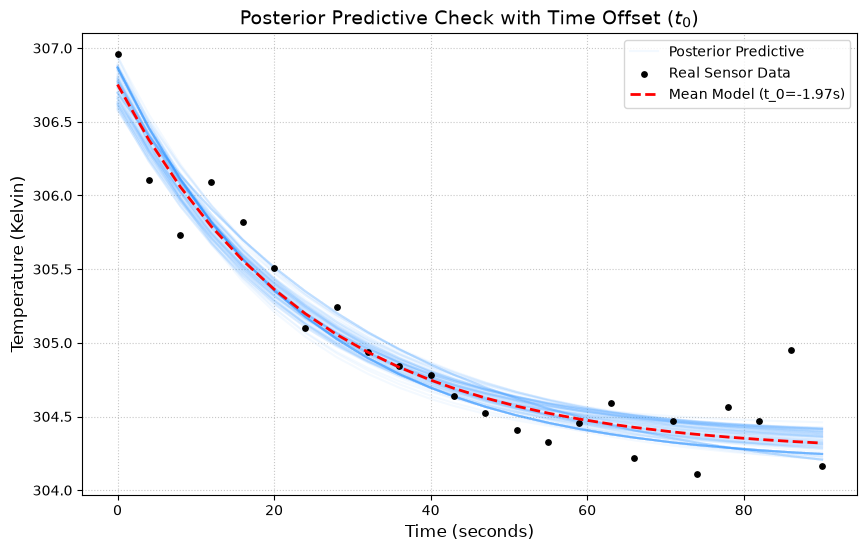

In [75]:
plot_posterior_predictive(history, time_steps, sensor_data, T0, num_samples=100)

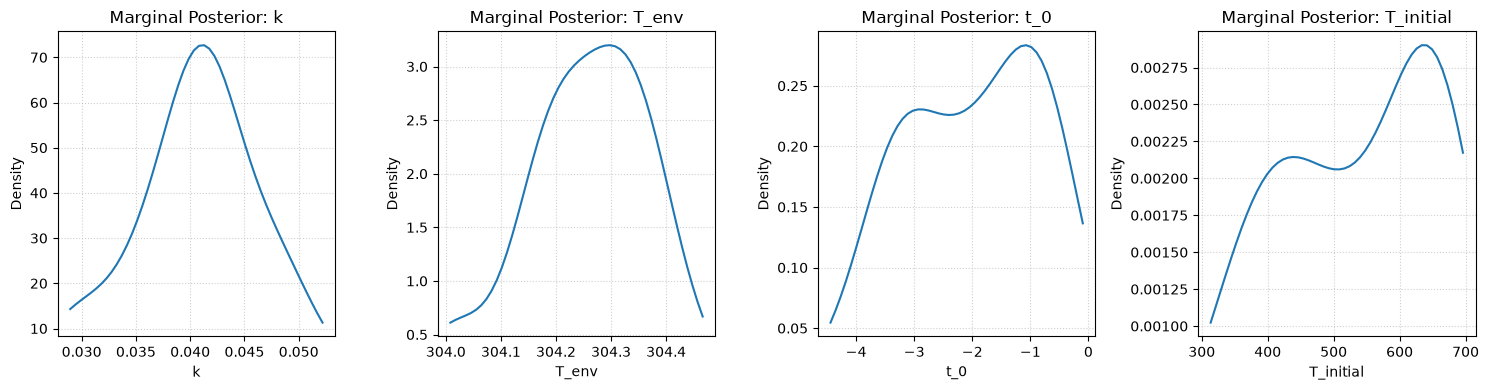

In [76]:
from pyabc.visualization import plot_kde_1d

def plot_homoscedastic_marginals(history):
    df_params, w = history.get_distribution(m=0, t=history.max_t)
    
    params = ["k", "T_env", "t_0", "T_initial"]
    
    # Create a 1x3 grid
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    
    for i, param in enumerate(params):
        plot_kde_1d(df_params, w, x=param, ax=axes[i])
        axes[i].set_title(f"Marginal Posterior: {param}", fontsize=12)
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].set_ylabel("Density")
        
    plt.tight_layout()
    plt.show()

# Execute using your existing history object
plot_homoscedastic_marginals(history)